# Description

Notebook to create a sin based dataset

In [23]:
import os
import sys

CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from typing import List

# Locals
from utils import *
from dataset import DFDataset, TensorDataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction

In [25]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [27]:
def polinomial_function_2variable(x0:float, x1:float):
    """
    Function that takes in two values x0 and x1 and returns its polinomial value.

    Args:
        x0 (float): 1st dimension value to be transformed.
        x1 (float): 2nd dimension value to be transformed.

    Returns:
        float: result of the polinomial function.
    """
    # return np.sin(np.sqrt(x0**2 + x1**2))
    return x0**2 + x1**2


def add_gaussian_noise(df:pd.DataFrame, columns:List[str], mean:float = 0.0, std:float = 0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df

In [28]:
X_train = np.array([np.random.normal(size=3000), np.random.normal(size=3000)]).T
X_train = pd.DataFrame(X_train, columns=['x0', 'x1'])
y_train = polinomial_function_2variable(X_train['x0'], X_train['x1'])

df_train = pd.concat([X_train, pd.DataFrame(y_train, columns=['y'])], axis=1)

In [29]:
scaler = MinMaxScaler()
df_train = pd.DataFrame(scaler.fit_transform(df_train), columns=df_train.columns)
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
x0,3000.0,0.515464,0.137593,0.0,0.422669,0.514149,0.604778,1.0
x1,3000.0,0.497737,0.138347,0.0,0.404583,0.500063,0.592583,1.0
y,3000.0,0.134240,0.134650,0.0,0.038591,0.095078,0.182536,1.0


Text(0.5, 0, 'y')

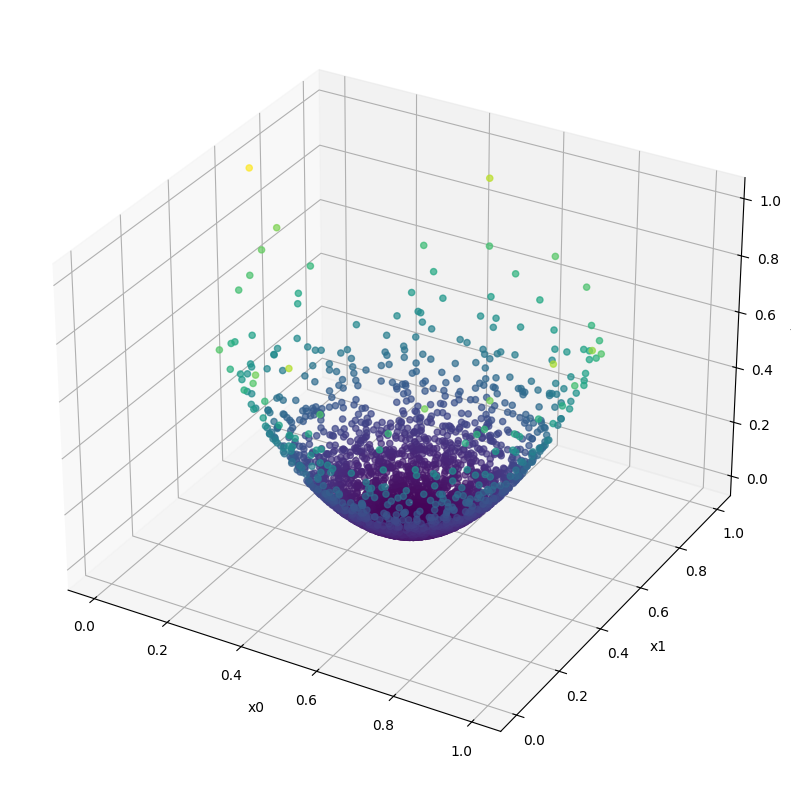

In [30]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_train['x0'], df_train['x1'], df_train['y'], marker='o', c=df_train['y'], cmap='viridis', alpha=0.7)

ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('y')

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    df_train[['x0', 'x1']].values, df_train['y'].values, test_size=0.2, random_state=42
)

In [32]:
model_params = {
    'ridge': {"alpha": 1.0},
    'pls': {"n_components": 2},
    'tree': {"max_depth": 5},
    'svm': {"kernel": 'rbf'},
    # 'svm': {"kernel": 'poly', "degree": 2},	
    'knn': {"n_neighbors": 5, "weights": 'uniform', "algorithm": 'auto', "leaf_size": 30, "p": 2, "n_jobs": None},
}
xai_benchmark = XAI_benchmark(is_ts = False, model_params = model_params)

In [33]:
xai_benchmark.fit(X_train, y_train)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Machine model...
Fitting K-Nearest Neighbours model...
All models fitted!


In [34]:
xai_benchmark.predict(X_test, y_test, get_metrics=True)

({'ridge': array([0.13131169, 0.13991596, 0.13543338, 0.13336645, 0.13648172,
         0.13300633, 0.13223226, 0.12946199, 0.13506542, 0.13841422,
         0.13560043, 0.13170013, 0.12837154, 0.13516453, 0.13400479,
         0.13176861, 0.12954506, 0.13787973, 0.13151683, 0.12878331,
         0.13997935, 0.1249026 , 0.13779044, 0.12774597, 0.12732622,
         0.13618349, 0.13429119, 0.13280637, 0.13545368, 0.13874922,
         0.1355481 , 0.14096385, 0.132832  , 0.12992742, 0.13286316,
         0.13185592, 0.13626146, 0.13198241, 0.13191455, 0.12558418,
         0.1268487 , 0.1383367 , 0.1387169 , 0.12985209, 0.1408914 ,
         0.13043522, 0.12940654, 0.13584387, 0.13520059, 0.12950083,
         0.1281944 , 0.13146486, 0.13751132, 0.13511297, 0.13540154,
         0.13428639, 0.13673545, 0.13104931, 0.12881083, 0.134434  ,
         0.12978566, 0.13938017, 0.13401972, 0.12712069, 0.13555206,
         0.13133145, 0.13537218, 0.12396938, 0.13743466, 0.1370378 ,
         0.13363048, 0.13

In [35]:
sigma = 0.02
df_noisy = add_gaussian_noise(
        df=df_train.copy(),
        columns=df_train.columns,
        mean=0,
        std=sigma
)

In [36]:
X_train_noisy, X_val_noisy, y_train_noisy, y_val_noisy = train_test_split(
    df_noisy[['x0', 'x1']].values, df_noisy['y'].values, test_size=0.2, random_state=42
)

Text(0.5, 0, 'y')

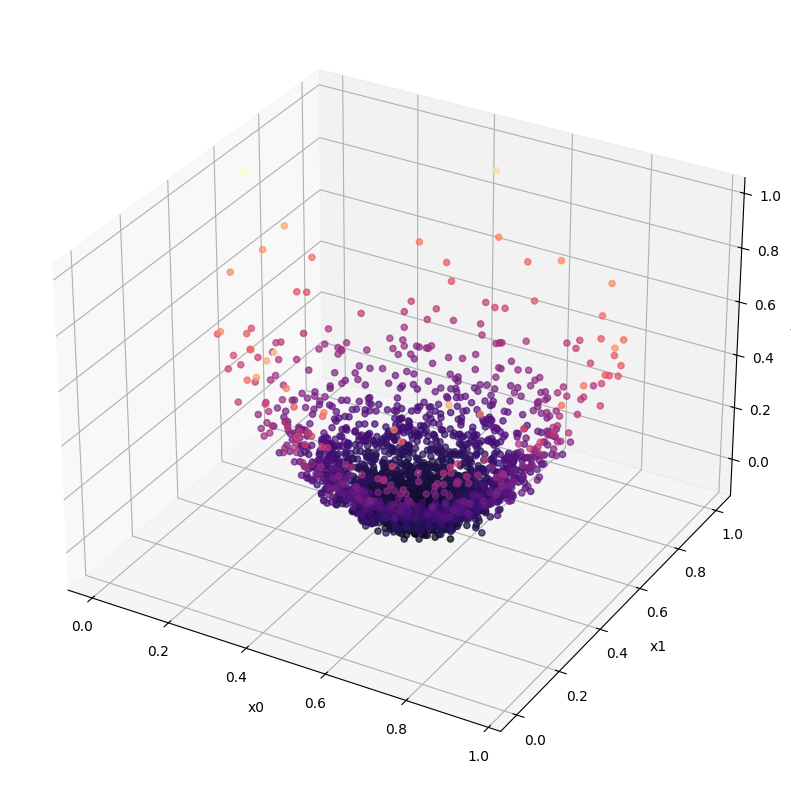

In [37]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_train_noisy[:,0],
    X_train_noisy[:,1],
    y_train_noisy,
    marker='o',
    c=y_train_noisy,
    cmap='magma',
    alpha=0.7
)

ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('y')

In [38]:
# Transform the data into a tensor
# dataset_train = DFDataset(
#     input_df=pd.DataFrame(X_train_noisy, columns=['x0', 'x1']),
#     target_df=pd.DataFrame(y_train_noisy, columns=['y'])
# )
# # Transform the data into a tensor
# dataset_val = DFDataset(
#     input_df=pd.DataFrame(X_val_noisy, columns=['x0', 'x1']),
#     target_df=pd.DataFrame(y_val_noisy, columns=['y'])
# )
dataset_train = TensorDataset(
    x=X_train_noisy,
    y=y_train_noisy.reshape(-1,1)
)
# Transform the data into a tensor
dataset_val = TensorDataset(
    x=X_val_noisy,
    y=y_val_noisy.reshape(-1,1)
)

# Create the dataloaders
batch_size = 64
train_dataloader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=0)
val_dataloader = DataLoader(dataset_val, batch_size=batch_size, shuffle=True, num_workers=0)

In [39]:
model = GridFullyDenseNN(
    n_layers=2,
    hidden_layers=[
        (2, 1024),
        (1024, 1),
    ],
    dropout_layers=[
        0.0,
        0.0,
    ],
    activation_func_layers=[
        nn.ReLU(),
        nn.Identity(),
    ],
    want_dropout=[
        False,
        False,
    ],
    want_linear=[
        True,
        True,
    ],
    want_activation=[
        True,
        False,
    ],
)
model.to(device)

GridFullyDenseNN(
  (model): Sequential(
    (linear_0): Linear(in_features=2, out_features=1024, bias=True)
    (activation_0): ReLU()
    (linear_1): Linear(in_features=1024, out_features=1, bias=True)
  )
)

In [40]:
lr = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Define the trainer
trainer_basic = Trainer(
    model=model,
    train_generator=train_dataloader,
    val_generator=val_dataloader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    epoch_scheduler=None,
    batch_scheduler=None,
    patience=15,
    epochs=500,
    checkpoints_path=os.path.join(CHECKPOINT_PATH, f'model_noise_{sigma}_2variables'),
)

In [41]:
model, train_losses, val_losses, best_train_loss, best_val_loss = trainer_basic.fit(verbose=True)

Training is started!


Epochs loop:   9%| | 45/500 [00:23<04:02,  1.88epoch/s, Train loss: 0.0011783702

Training stopped as validation loss did not improve for 15 epochs.


In [42]:
# model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, f'model_sin_noise_{sigma}_2variables.pth')))

In [43]:
y_pred_train = model(torch.tensor(df_noisy[['x0', 'x1']].values.reshape(-1, 2)).float().to(device)).cpu().detach().numpy().reshape(-1)
y_pred_val = model(torch.tensor(X_val_noisy).float().to(device)).cpu().detach().numpy().reshape(-1)
# y_pred_test = model(torch.tensor(df_test[['x0', 'x1']].values.reshape(-1, 2)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [44]:
mae = mean_absolute_error(y_val_noisy, y_pred_val)
mse = mean_squared_error(y_val_noisy, y_pred_val)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_val_noisy - y_pred_val) / y_val_noisy)) * 100
r_squared = r2_score(y_val_noisy, y_pred_val)
print("MAE: ", mae)
print("MAPE: ", mape)
print("RMSE: ", rmse)
print("MSE: ", mse)
print("R-squared: ", r_squared)

MAE:  0.025754063853192247
MAPE:  60.912400615351004
RMSE:  0.03350238875537554
MSE:  0.0011224100523163133
R-squared:  0.9394457536983187


In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_noisy['x0'], df_noisy['x1'], df_noisy['y'], marker='*', c=df_noisy['y'], cmap='magma', alpha=0.5)
ax.scatter(df_noisy['x0'], df_noisy['x1'], y_pred_train, marker='o', c=y_pred_train, cmap='viridis', alpha=0.5)
ax.legend(['Noisy', 'Predicted'])

ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('y')

# Gradients to reduce noise

In [ ]:
df_no_noise = df_noisy.copy()
dlnr = DLNoiseReduction(model=model, criterion=criterion)
dlnr.fit(df_noisy[['x0', 'x1']].values, df_noisy[['y']].values)

In [ ]:
df_no_noise[['x0', 'x1']], df_no_noise['y'] = dlnr.transform(
                                                nrr=0.01,
                                                nr_threshold=0.01,
                                                max_epochs=500,
                                                plot_progress=False
                                            )

In [ ]:
df_no_noise[['x0', 'x1']], df_no_noise['y'] = dlnr.fit_transform(
    X=df_noisy[['x0', 'x1']].values,
    y=df_noisy[['y']].values,
    nrr=0.05,
    nr_threshold=0.01,
    max_epochs=100,
    plot_progress=True,
    path_to_save_imgs=None
)

In [ ]:
dlnr.assert_improvement(
    x_denoised = df_no_noise[['x0', 'x1']].values.reshape(-1, 2),
    y_denoised = df_no_noise[['y']].values.reshape(-1, 1),
    x_orig = df_train[['x0', 'x1']].values.reshape(-1, 2),
    y_orig = df_train[['y']].values.reshape(-1, 1)
)